Read Files

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
clinical_data = pd.read_csv("datasets/clinical_data.csv")
lab_data1 = pd.read_csv("datasets/lab_data.csv")

For lab data, We need to use the most recent pre-operative measurement, consistent with clinical practice

In [3]:
preop = lab_data1[(lab_data1['dt'] < 0) & (lab_data1['dt'] >= -43200)]

preop_last = (preop.sort_values('dt').groupby(['caseid', 'name']).last()   
              .reset_index()[['caseid','dt', 'name', 'result']])

preop_last.head(10)

,caseid,dt,name,result
0,1,-38769,cl,100.0
1,1,-38769,k,3.5
2,1,-38769,na,141.0
3,4,-36197,cl,108.0
4,4,-36197,k,4.3
5,4,-36197,na,144.0
6,5,-2968,alb,4.6
7,5,-2968,alt,30.0
8,5,-699,aptt,36.5
9,5,-2968,ast,64.0


In [4]:
preop.groupby("name")["dt"].describe()

,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
alb,434.0,-24219.311060,12405.602720,-43052.0,-35528.50,-24365.5,-14642.25,-37.0
alt,419.0,-24072.064439,12339.799110,-42933.0,-35407.00,-24274.0,-14663.50,-37.0
ammo,6.0,-22137.166667,8851.573271,-33070.0,-26473.50,-24945.5,-16411.00,-9313.0
aptt,363.0,-24148.564738,12504.731430,-43089.0,-35804.50,-24147.0,-14341.50,-33.0
ast,419.0,-24072.064439,12339.799110,-42933.0,-35407.00,-24274.0,-14663.50,-37.0
be,70.0,-17935.928571,13057.035411,-43068.0,-29898.25,-13892.0,-7140.75,-1476.0
bun,491.0,-23064.981670,12231.010198,-43074.0,-34383.50,-22681.0,-14339.00,-37.0
ccr,24.0,-22605.250000,11595.638191,-42332.0,-30263.50,-18678.0,-13940.00,-1335.0
cl,992.0,-27004.285282,11462.747424,-43174.0,-35115.50,-31231.5,-18411.50,-37.0


In [5]:
#preop_last.to_excel("preop_lab_values.xlsx", index=False)

Change the row x column using piviot table in sheet 2

In [6]:
lab_data = (preop_last
            .pivot(index="caseid", columns="name", values="result")
            .reset_index())
lab_data.columns.name = None

lab_cols = [c for c in lab_data.columns if c != "caseid"]
lab_data[lab_cols] = lab_data[lab_cols].apply(pd.to_numeric, errors="coerce")

lab_data.head(10)

,caseid,alb,alt,ammo,aptt,ast,be,bun,ccr,cl,...,ph,plt,po2,pt%,ptinr,ptsec,sao2,tbil,tprot,wbc
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,4.6,30.0,NaN,36.5,64.0,NaN,27.0,NaN,108.0,...,NaN,158.0,NaN,81.0,1.14,13.0,NaN,0.9,8.2,14.64
3,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20,NaN,NaN,NaN,33.3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,58.0,1.43,16.4,NaN,NaN,NaN,NaN
5,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,52,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,105.0,...,NaN,242.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.67
9,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,346.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.70


remove the coumns that has less than 75% of missing data

In [7]:
missing_rate = lab_data.isna().mean()
lab_data = lab_data.loc[:, missing_rate < 0.75]
lab_data


,caseid,alb,alt,aptt,ast,bun,cl,cr,fib,gfr,...,hct,k,na,plt,pt%,ptinr,ptsec,tbil,tprot,wbc
0,1,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,...,NaN,3.5,141.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,NaN,NaN,NaN,NaN,NaN,108.0,NaN,NaN,NaN,...,NaN,4.3,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,4.6,30.0,36.5,64.0,27.0,108.0,1.83,178.0,37.2,...,45.2,4.9,139.0,158.0,81.0,1.14,13.0,0.9,8.2,14.64
3,17,NaN,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,...,NaN,4.4,141.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20,NaN,NaN,33.3,NaN,NaN,NaN,NaN,543.0,NaN,...,NaN,NaN,NaN,NaN,58.0,1.43,16.4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1198,6368,NaN,NaN,NaN,NaN,NaN,106.0,NaN,NaN,NaN,...,NaN,3.4,139.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1199,6380,NaN,NaN,NaN,NaN,NaN,104.0,NaN,NaN,NaN,...,NaN,3.4,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1200,6383,NaN,NaN,NaN,NaN,34.0,99.0,6.70,NaN,9.3,...,31.0,3.7,141.0,202.0,NaN,NaN,NaN,NaN,NaN,5.01
1201,6386,NaN,NaN,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,4.5,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Box_plots

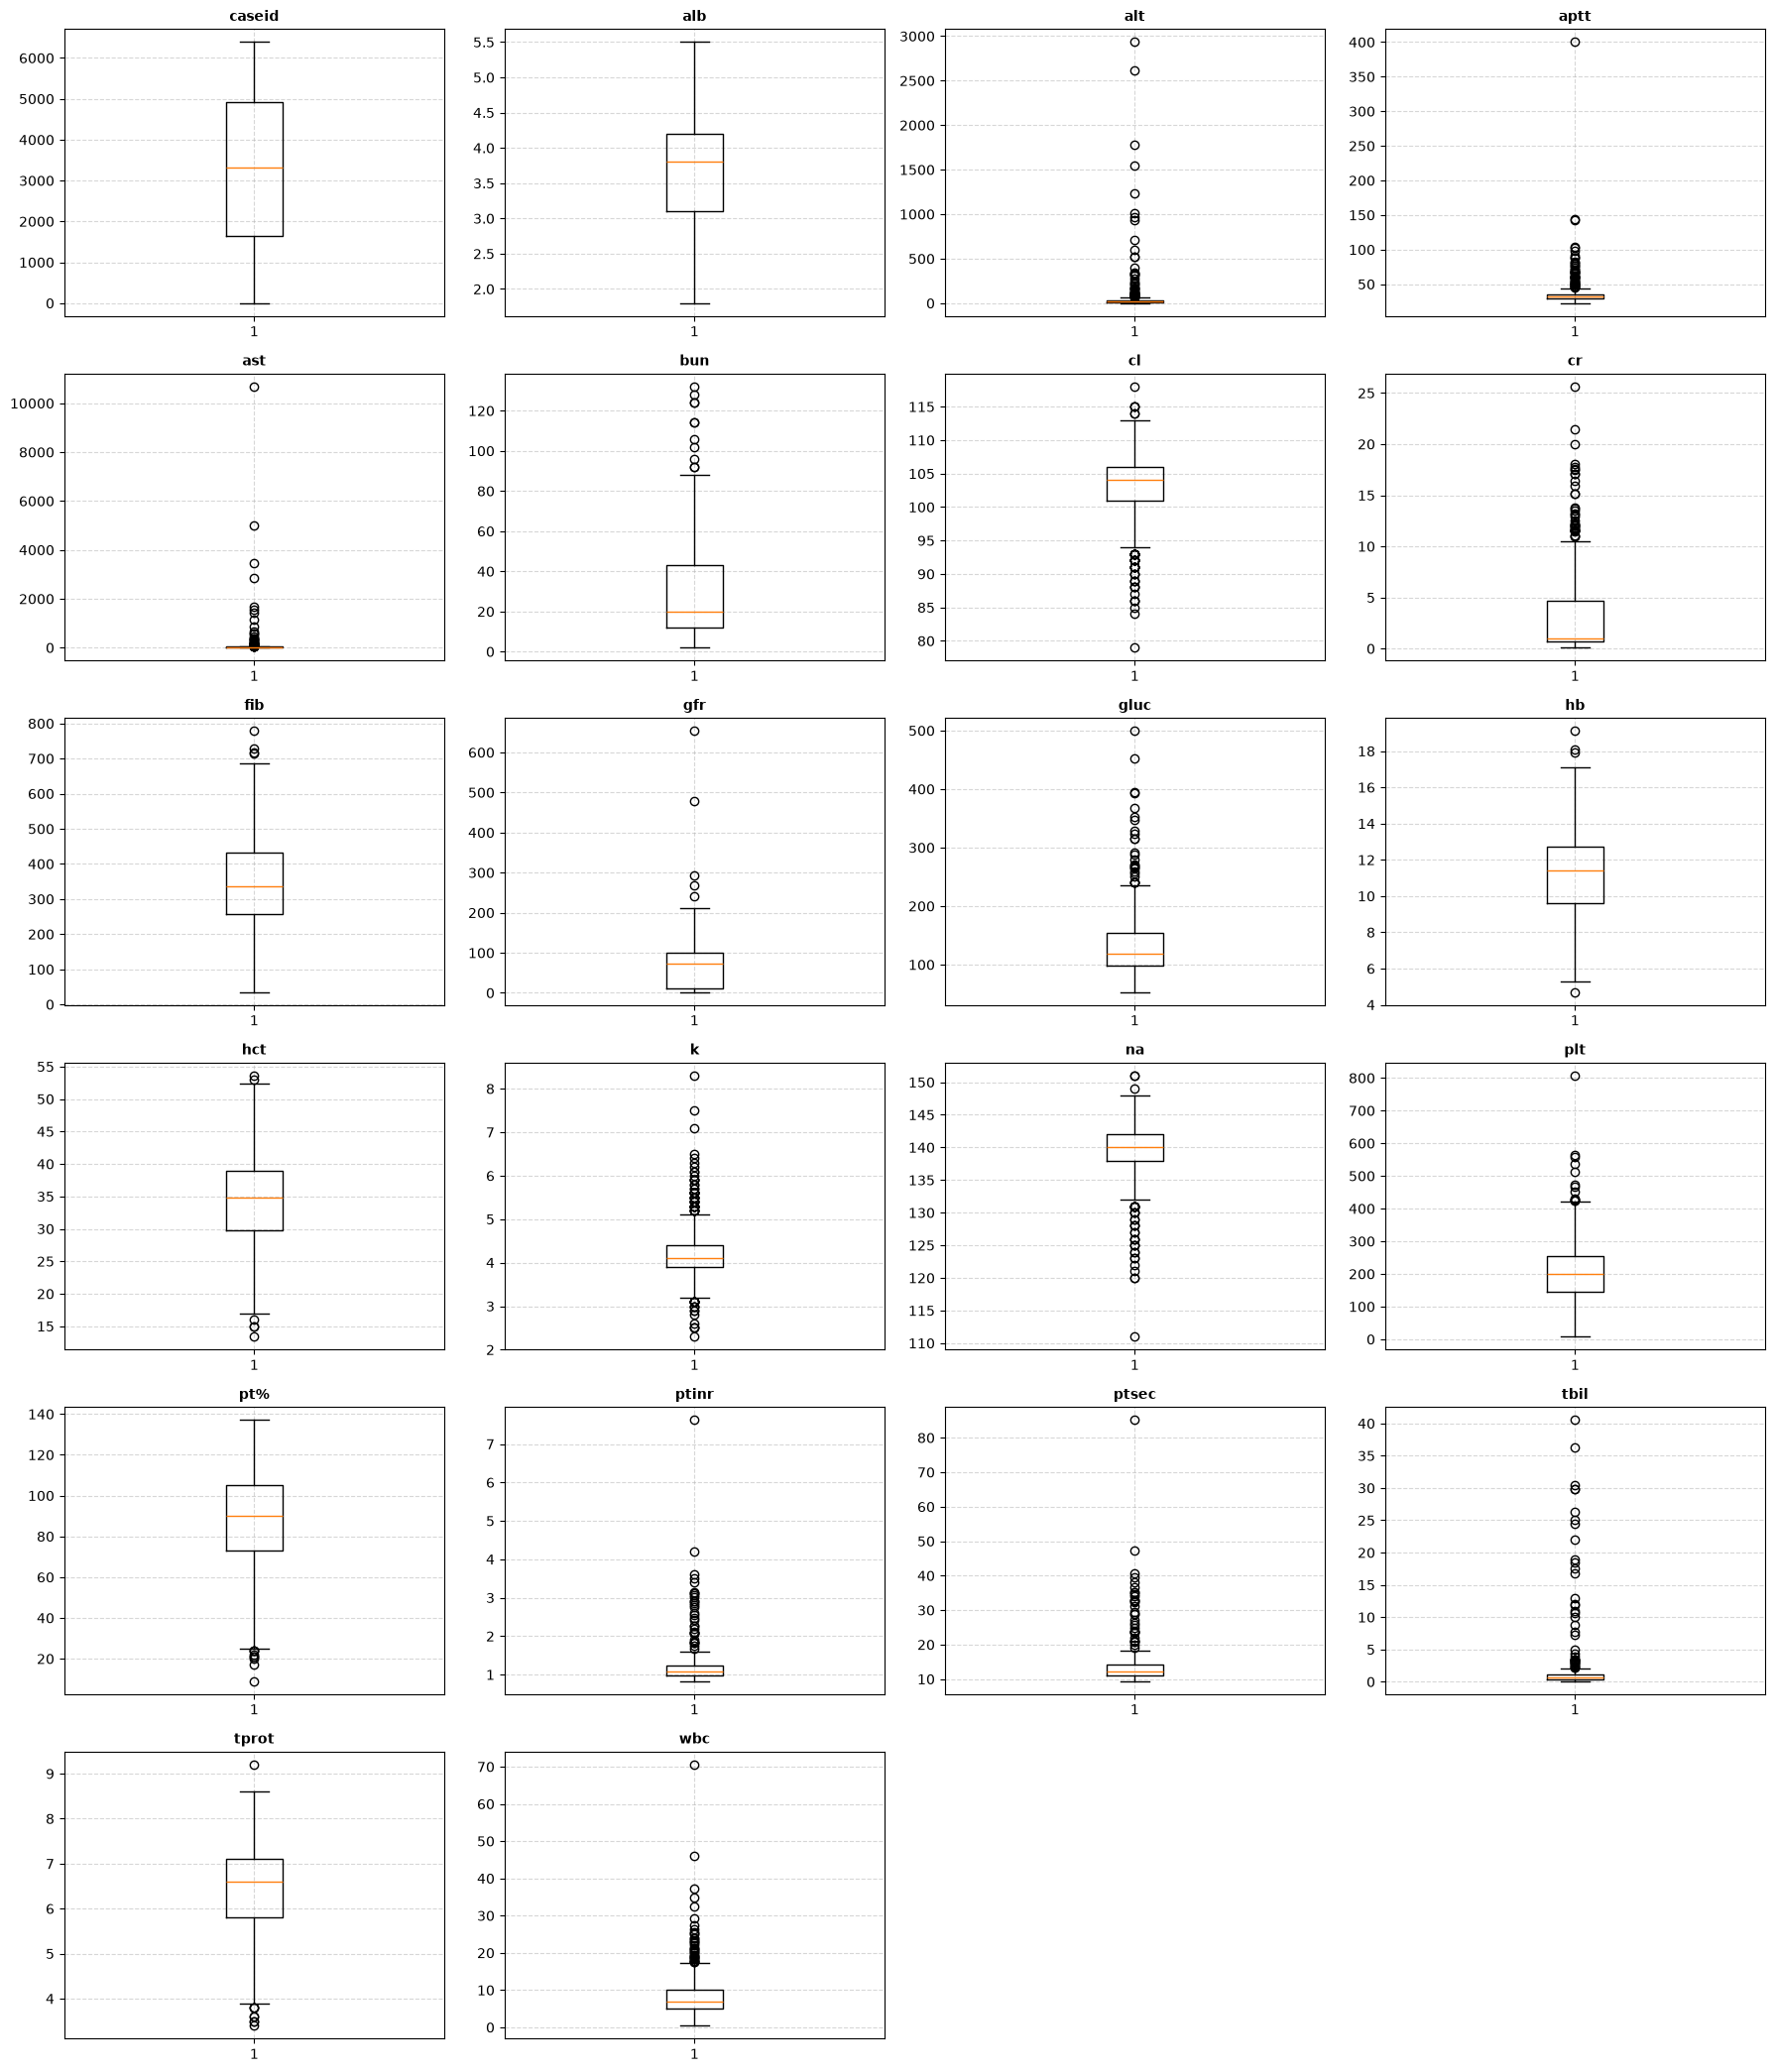

In [8]:
import math
import matplotlib.pyplot as plt
import pandas as pd


columns_to_check = []
for col in lab_data.columns:
    if "Unnamed" not in str(col):
        clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()
        if not clean_data.empty:
            columns_to_check.append(col)

#Calculate total rows needed for 6 per row
num_plots = len(columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))


for i, col in enumerate(columns_to_check, start=1):
    clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()

    plt.subplot(num_rows, 4, i)  # (rows, columns, plot number)
    plt.boxplot(clean_data)
    plt.title(col, fontsize=10, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Histogram of lab values

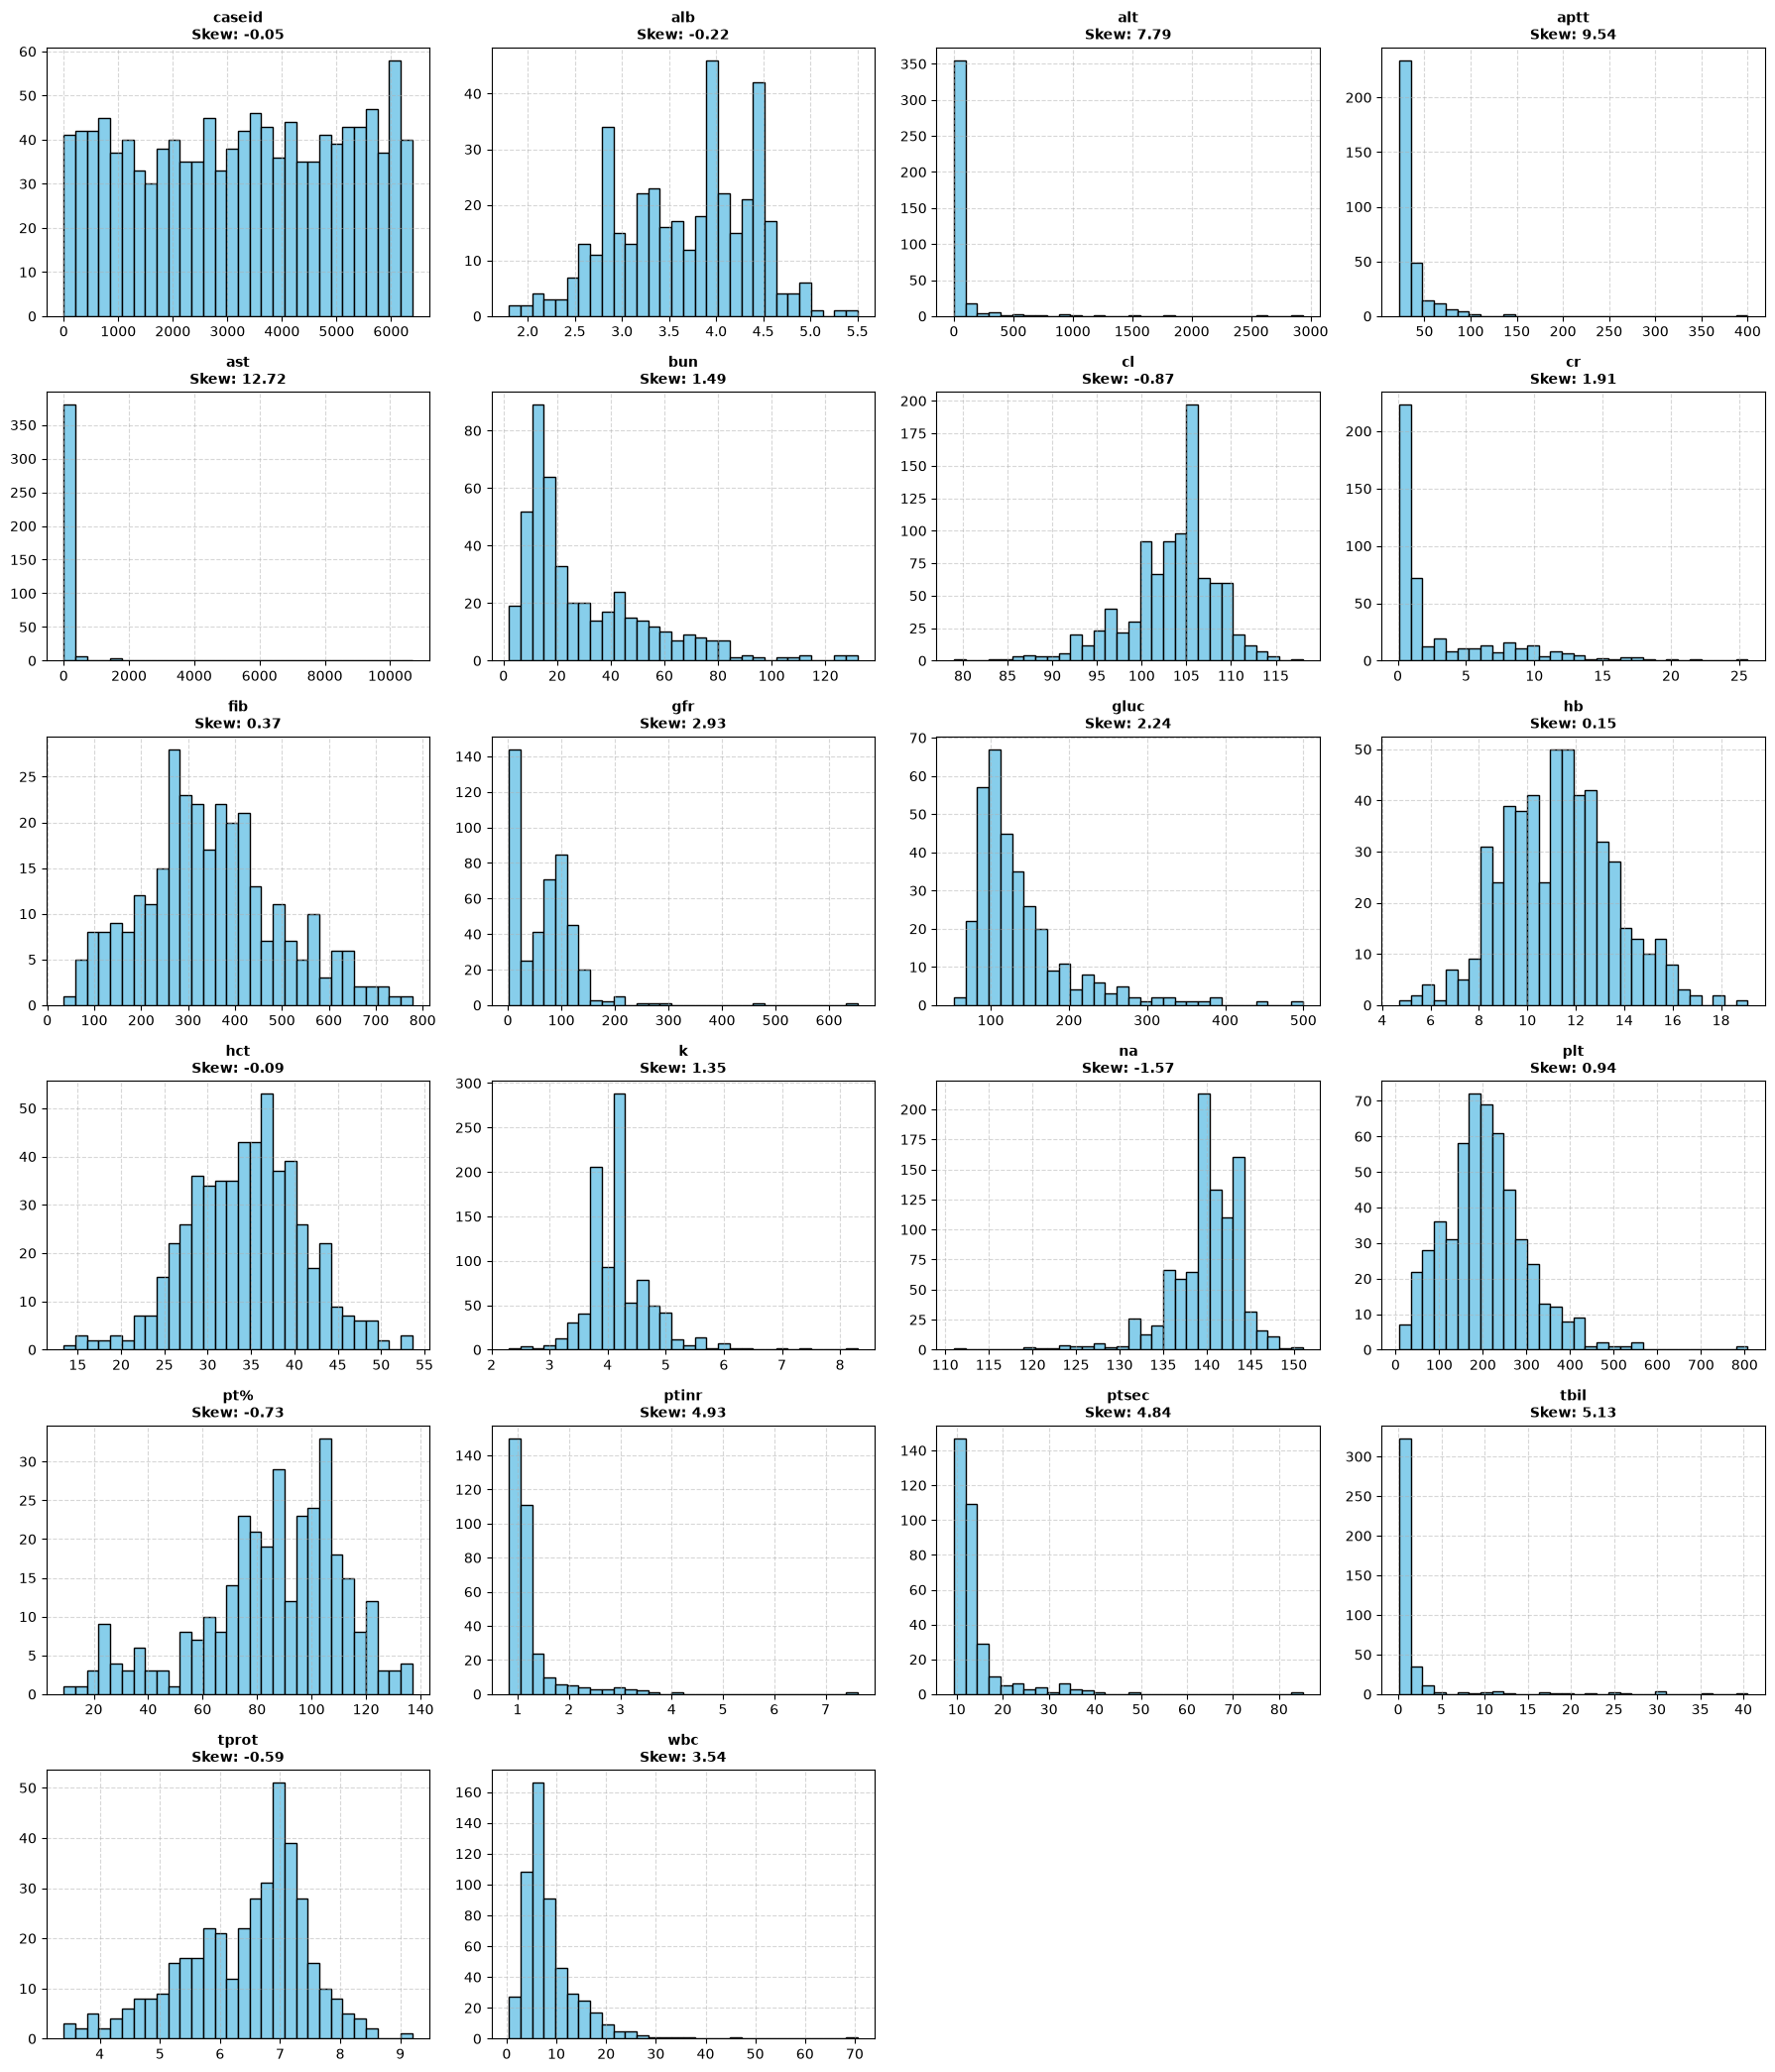

In [9]:

columns_to_check = []
for col in lab_data.columns:
    if "Unnamed" not in str(col):
        clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()
        if not clean_data.empty:
            columns_to_check.append(col)

#Calculate total rows needed for 6 per row
num_plots = len(columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))

for i, col in enumerate(columns_to_check, start=1):
    clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()

    col_skew = clean_data.skew()

    plt.subplot(num_rows, 4, i)
    plt.hist(clean_data, bins=30, color="skyblue", edgecolor="black")
    plt.title(f"{col}\nSkew: {col_skew:.2f}", fontsize=10, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

histogram of numerical clinical values

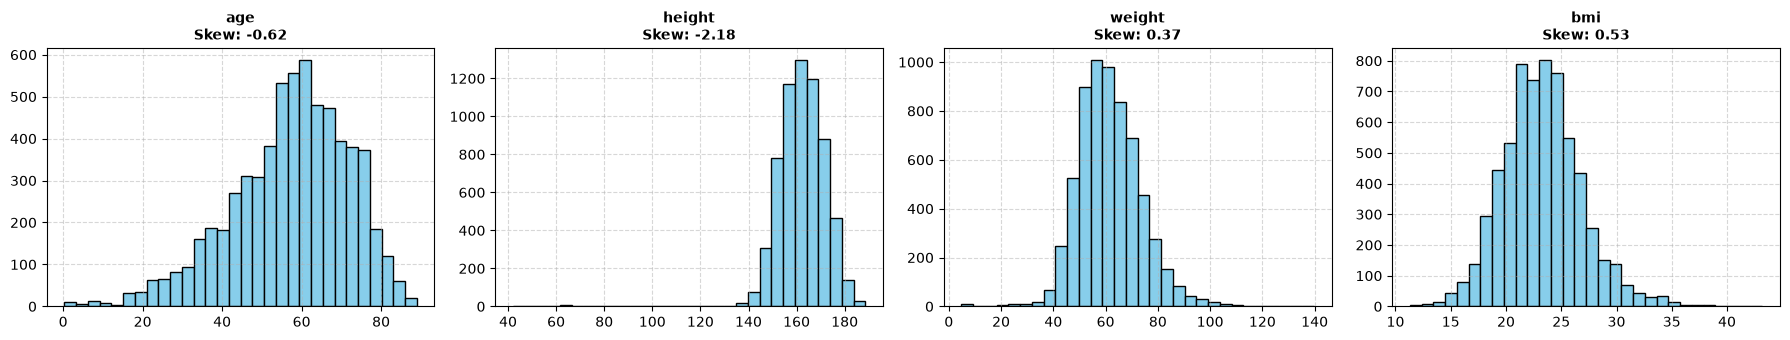

In [10]:
clinical_columns_to_check = ["age", "height", "weight", "bmi"]

num_plots = len(clinical_columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))

for i, col in enumerate(clinical_columns_to_check, start=1):
    clean_data = pd.to_numeric(clinical_data[col], errors="coerce").dropna()

    col_skew = clean_data.skew()

    plt.subplot(num_rows, 4, i)
    plt.hist(clean_data, bins=30, color="skyblue", edgecolor="black")
    plt.title(f"{col}\nSkew: {col_skew:.2f}", fontsize=10, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

clean clinical value

In [11]:
clinical_data["age"] = clinical_data["age"].replace(">89", 90)
clinical_data["age"] = pd.to_numeric(clinical_data["age"], errors="coerce")

coleration of with clinical numerical vlaues

(1203, 95)
              hb       hct
age     0.010649 -0.011158
height  0.140468  0.139207
weight  0.251358  0.259905
bmi     0.244061  0.246052
F 565
age       0.040439
height    0.206498
weight    0.297482
bmi       0.221647
hct       1.000000
Name: hct, dtype: float64
M 638
age      -0.047945
height    0.086813
weight    0.252773
bmi       0.265565
hct       1.000000
Name: hct, dtype: float64


<Axes: >

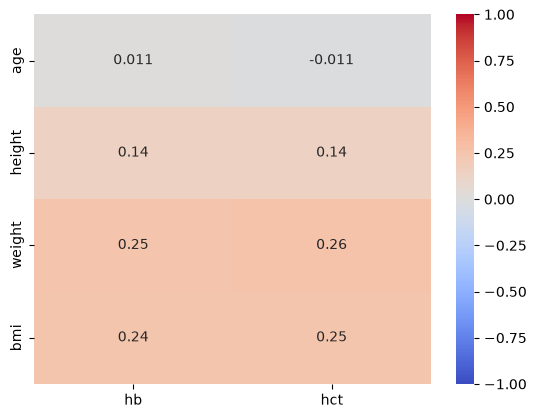

In [12]:
merged = clinical_data.merge(lab_data, on="caseid", how="inner")
print(merged.shape)  
clinical_vars = ["age","height", "weight", "bmi"]
lab_vars = ["hb", "hct"]

corr_matrix = merged[clinical_vars + lab_vars].corr(method="spearman")
cross_corr = corr_matrix.loc[clinical_vars, lab_vars]
print(cross_corr)

merged["sex_bin"] = (merged["sex"] == "M").astype(int) # will be used for interaction terms in modelling phase

for s, grp in merged.groupby("sex"):
    print(s, len(grp))
    print(grp[["age","height","weight","bmi","hct"]].corr(method="spearman")["hct"])

sns.heatmap(cross_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

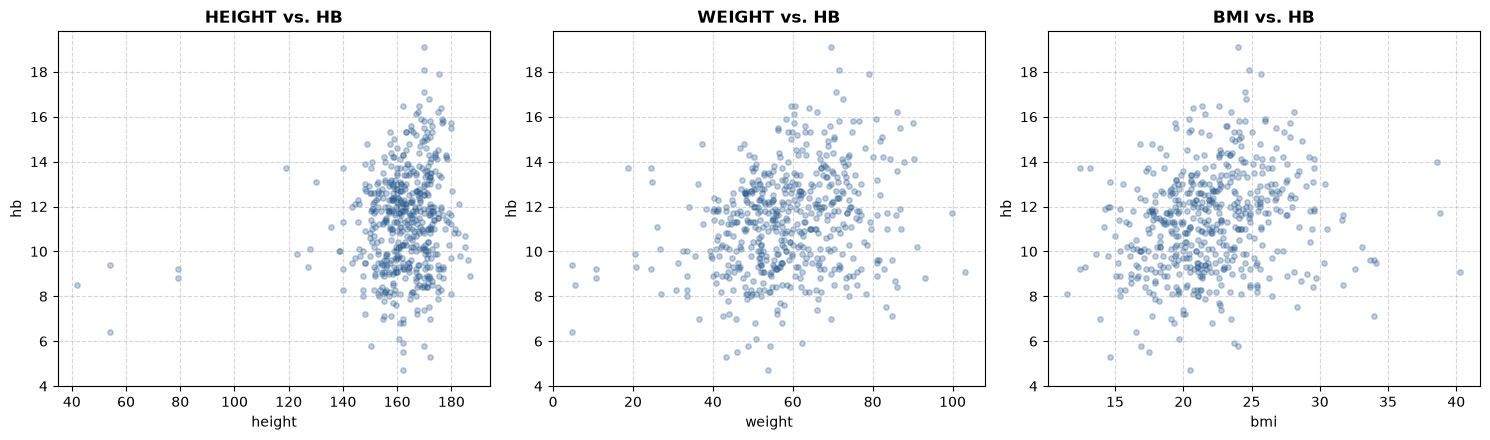

In [13]:
# List of clinical variables for the x-axis
x_vars = ["height", "weight", "bmi"]
y_var = "hb"

# Create a 1-row, 3-column figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, x_col in enumerate(x_vars):
    # Drop rows where either x or y is NaN for a clean plot
    valid_data = merged[[x_col, y_var]].dropna()

    axes[i].scatter(
        valid_data[x_col], valid_data[y_var], alpha=0.3, color="#2b5c8f", s=15
    )
    axes[i].set_title(f"{x_col.upper()} vs. {y_var.upper()}", fontweight="bold")
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_var)
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

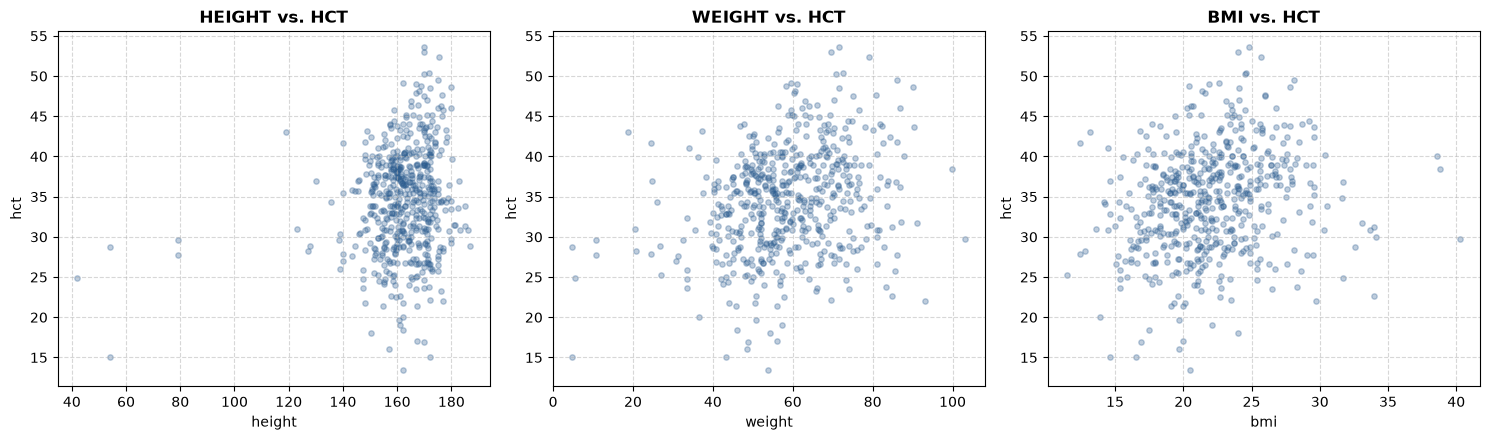

In [14]:
# List of clinical variables for the x-axis
x_vars = ["height", "weight", "bmi"]
y_var = "hct"

# Create a 1-row, 3-column figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, x_col in enumerate(x_vars):
    # Drop rows where either x or y is NaN for a clean plot
    valid_data = merged[[x_col, y_var]].dropna()

    axes[i].scatter(
        valid_data[x_col], valid_data[y_var], alpha=0.3, color="#2b5c8f", s=15
    )
    axes[i].set_title(f"{x_col.upper()} vs. {y_var.upper()}", fontweight="bold")
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_var)
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

combined features against hb

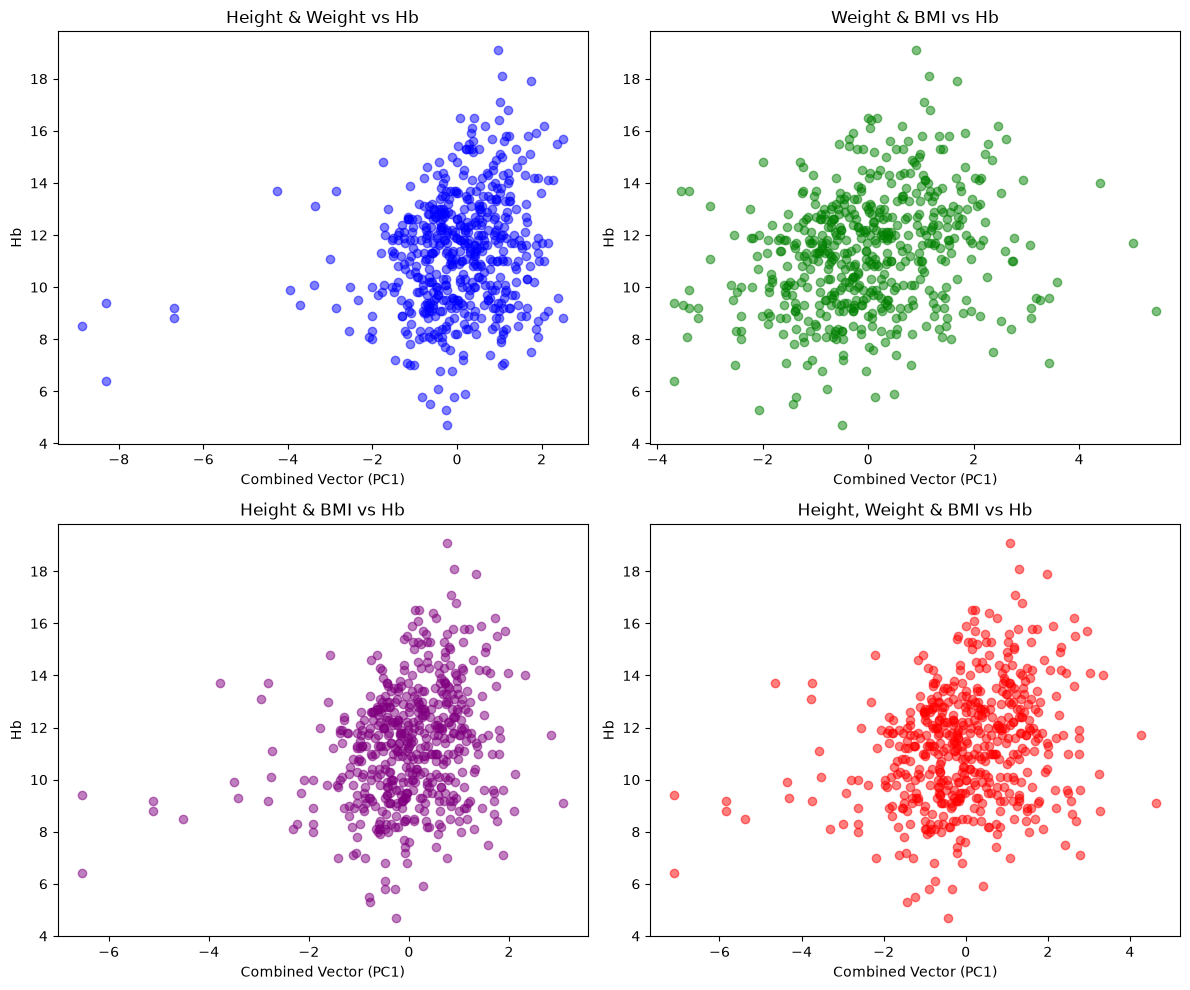

In [15]:
features = ["height", "weight", "bmi"]
for col in features + ["hb"]:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

#drop rows with missing data
clean_data = merged.dropna(subset=features + ["hb"]).copy()

#z score normalization
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(clean_data[features])

clean_data["scaled_height"] = scaled_matrix[:, 0] #column 0 is height, all rows
clean_data["scaled_weight"] = scaled_matrix[:, 1]
clean_data["scaled_bmi"] = scaled_matrix[:, 2]

#function to create a matix with multiple features
def combine_to_1d(feature_columns):
    pca = PCA(n_components=1)
    combined_1d = pca.fit_transform(clean_data[feature_columns])
    return combined_1d.flatten()

vec_height_weight = combine_to_1d(["scaled_height", "scaled_weight"])
vec_weight_bmi = combine_to_1d(["scaled_weight", "scaled_bmi"])
vec_height_bmi = combine_to_1d(["scaled_height", "scaled_bmi"])
vec_all_three = combine_to_1d(["scaled_height", "scaled_weight", "scaled_bmi"])

target_hb = clean_data["hb"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Height & Weight vs Hb
axes[0, 0].scatter(vec_height_weight, target_hb, alpha=0.5, color="blue")
axes[0, 0].set_title("Height & Weight vs Hb")
axes[0, 0].set_xlabel("Combined Vector (PC1)")
axes[0, 0].set_ylabel("Hb")

#Weight & BMI vs Hb
axes[0, 1].scatter(vec_weight_bmi, target_hb, alpha=0.5, color="green")
axes[0, 1].set_title("Weight & BMI vs Hb")
axes[0, 1].set_xlabel("Combined Vector (PC1)")
axes[0, 1].set_ylabel("Hb")

#Height & BMI vs Hb
axes[1, 0].scatter(vec_height_bmi, target_hb, alpha=0.5, color="purple")
axes[1, 0].set_title("Height & BMI vs Hb")
axes[1, 0].set_xlabel("Combined Vector (PC1)")
axes[1, 0].set_ylabel("Hb")

#Height, Weight & BMI vs Hb
axes[1, 1].scatter(vec_all_three, target_hb, alpha=0.5, color="red")
axes[1, 1].set_title("Height, Weight & BMI vs Hb")
axes[1, 1].set_xlabel("Combined Vector (PC1)")
axes[1, 1].set_ylabel("Hb")

plt.tight_layout()
plt.show()

combined features against hct

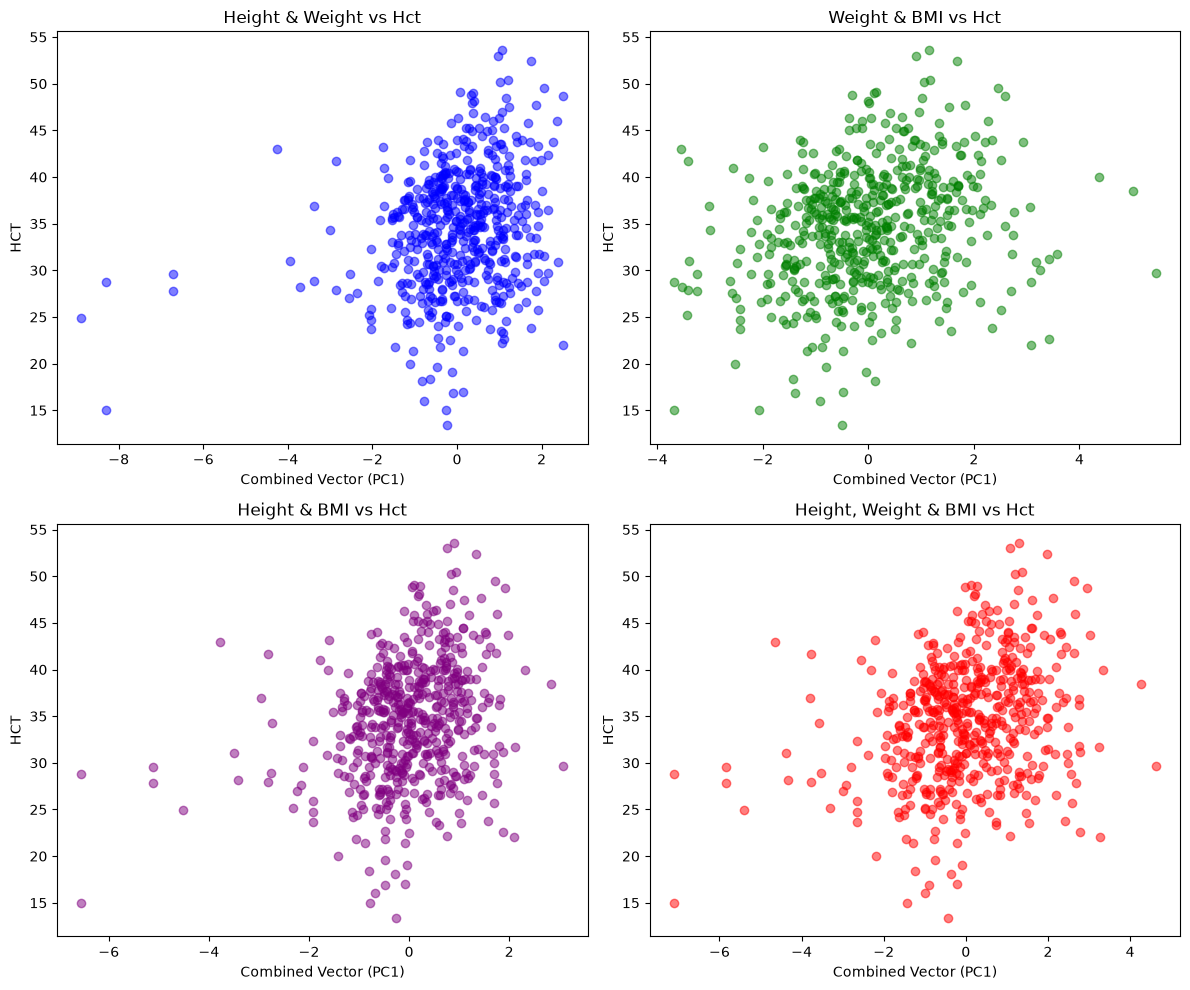

In [16]:
features = ["height", "weight", "bmi"]
for col in features + ["hct"]:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

#drop rows with missing data
clean_data = merged.dropna(subset=features + ["hct"]).copy()

#z score normalization
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(clean_data[features])

clean_data["scaled_height"] = scaled_matrix[:, 0] #column 0 is height, all rows
clean_data["scaled_weight"] = scaled_matrix[:, 1]
clean_data["scaled_bmi"] = scaled_matrix[:, 2]

#function to create a matix with multiple features
def combine_to_1d(feature_columns):
    pca = PCA(n_components=1)
    combined_1d = pca.fit_transform(clean_data[feature_columns])
    return combined_1d.flatten()

vec_height_weight = combine_to_1d(["scaled_height", "scaled_weight"])
vec_weight_bmi = combine_to_1d(["scaled_weight", "scaled_bmi"])
vec_height_bmi = combine_to_1d(["scaled_height", "scaled_bmi"])
vec_all_three = combine_to_1d(["scaled_height", "scaled_weight", "scaled_bmi"])

target_hct = clean_data["hct"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Height & Weight vs Hct
axes[0, 0].scatter(vec_height_weight, target_hct, alpha=0.5, color="blue")
axes[0, 0].set_title("Height & Weight vs Hct")
axes[0, 0].set_xlabel("Combined Vector (PC1)")
axes[0, 0].set_ylabel("HCT")

#Weight & BMI vs Hct
axes[0, 1].scatter(vec_weight_bmi, target_hct, alpha=0.5, color="green")
axes[0, 1].set_title("Weight & BMI vs Hct")
axes[0, 1].set_xlabel("Combined Vector (PC1)")
axes[0, 1].set_ylabel("HCT")

#Height & BMI vs Hct
axes[1, 0].scatter(vec_height_bmi, target_hct, alpha=0.5, color="purple")
axes[1, 0].set_title("Height & BMI vs Hct")
axes[1, 0].set_xlabel("Combined Vector (PC1)")
axes[1, 0].set_ylabel("HCT")

#Height, Weight & BMI vs Hct
axes[1, 1].scatter(vec_all_three, target_hct, alpha=0.5, color="red")
axes[1, 1].set_title("Height, Weight & BMI vs Hct")
axes[1, 1].set_xlabel("Combined Vector (PC1)")
axes[1, 1].set_ylabel("HCT")

plt.tight_layout()
plt.show()

histogram of with clinical categorical vlaues

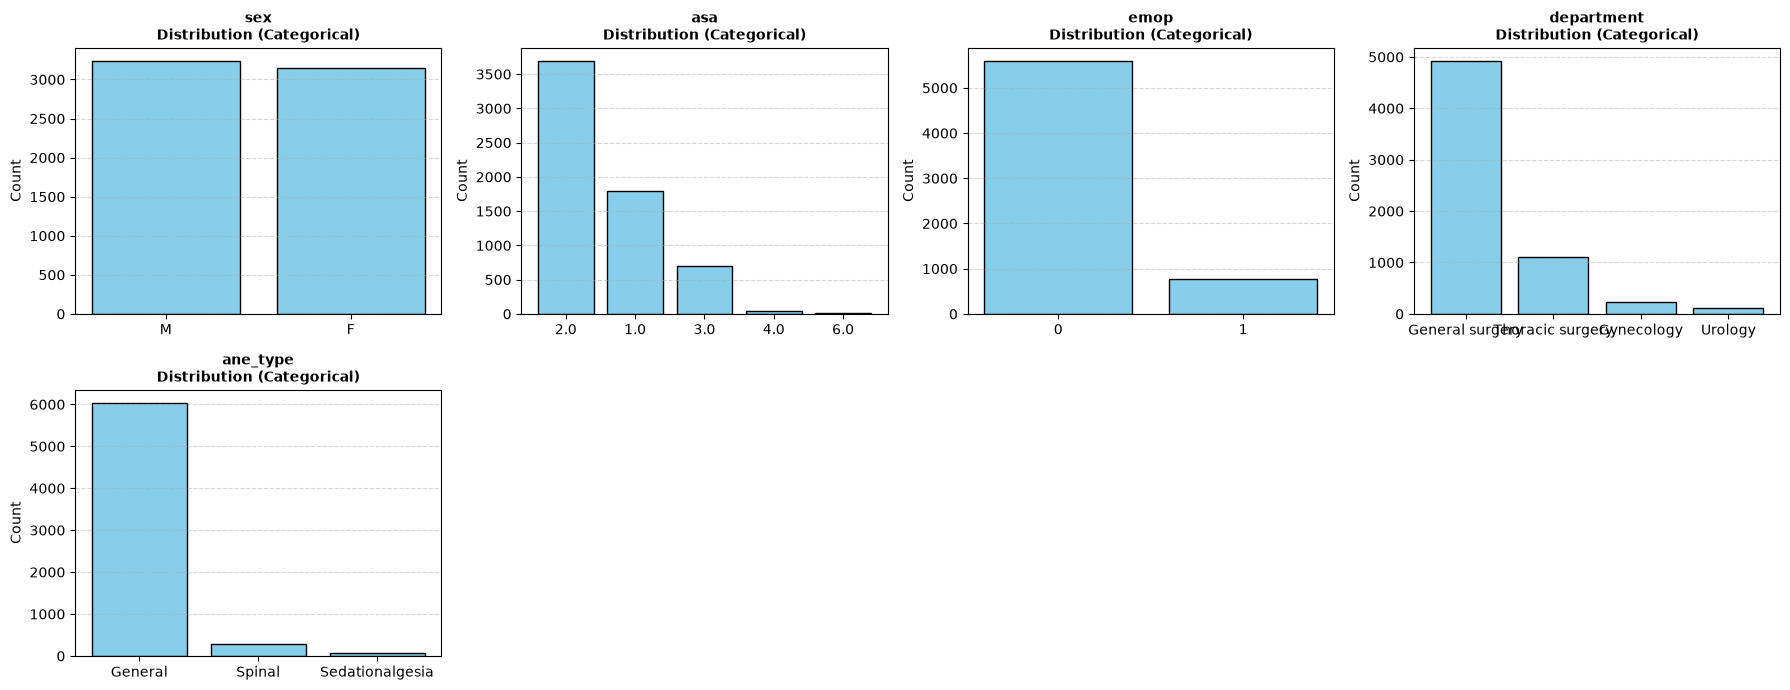

In [17]:
clinical_columns_to_check = ["sex","asa","emop","department","ane_type"]

num_plots = len(clinical_columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))

for i, col in enumerate(clinical_columns_to_check, start=1):
    # Drop missing values and count occurrences of 'M' and 'F'
    counts = clinical_data[col].dropna().value_counts()

    plt.subplot(num_rows, 4, i)
    plt.bar(
        counts.index.astype(str), counts.values, color="skyblue", edgecolor="black"
    )
    plt.title(f"{col}\nDistribution (Categorical)", fontsize=10, fontweight="bold")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Correlation Ratio ($\eta$, Eta)

Association (Correlation Ratio eta: 0 = none, 1 = perfect):
               hb    hct
sex         0.115  0.088
asa         0.438  0.439
emop        0.156  0.198
department  0.211  0.215
ane_type    0.103  0.091


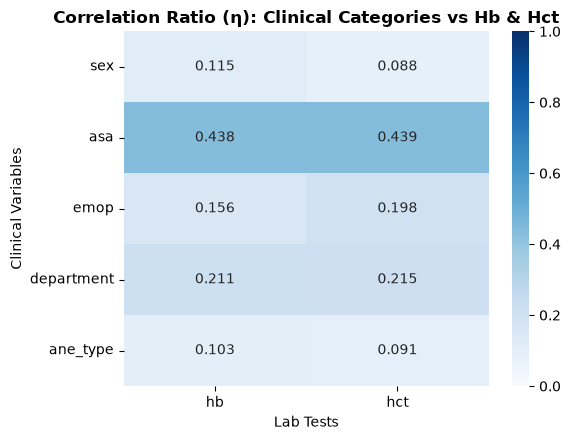

In [18]:
def correlation_ratio(categories, values):
    """Calculates Eta (association between categorical and continuous)."""
    valid = ~(categories.isna() | values.isna())
    cats = categories[valid].to_numpy()
    vals = values[valid].to_numpy()

    if len(vals) == 0:
        return np.nan

    y_mean = np.mean(vals)
    ss_total = np.sum((vals - y_mean) ** 2)
    if ss_total == 0:
        return 0.0

    ss_between = 0.0
    for cat in np.unique(cats):
        sub = vals[cats == cat]
        ss_between += len(sub) * (np.mean(sub) - y_mean) ** 2

    return np.sqrt(ss_between / ss_total)

clinical_vars = ["sex", "asa", "emop", "department", "ane_type"]
target_labs = ["hb", "hct"]


for col in target_labs:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

#Eta matrix
eta_matrix = pd.DataFrame(index=clinical_vars, columns=target_labs, dtype=float)

for clin in clinical_vars:
    for lab in target_labs:
        eta_matrix.loc[clin, lab] = correlation_ratio(merged[clin], merged[lab])


print("Association (Correlation Ratio eta: 0 = none, 1 = perfect):")
print(eta_matrix.round(3))

# heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    eta_matrix, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, cbar=True
)
plt.title("Correlation Ratio (η): Clinical Categories vs Hb & Hct", fontweight="bold")
plt.ylabel("Clinical Variables")
plt.xlabel("Lab Tests")
plt.tight_layout()
plt.show()

In [19]:
merged["age_x_sex"] = merged["age"] * merged["sex_bin"]

X = merged[["age", "height", "weight", "bmi", "sex_bin", "age_x_sex"]]

cols = ["age", "height", "weight", "bmi", "sex_bin", "age_x_sex", "hct"]
model_data = merged.dropna(subset=cols)
print(model_data.shape)

X = model_data[["age", "height", "weight", "bmi", "sex_bin", "age_x_sex"]]
y = model_data["hct"]

(543, 97)


OLS baseline model

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
scores_age = cross_val_score(model, model_data[["age"]], y, cv=5, scoring="r2")
scores_height = cross_val_score(model, model_data[["height"]], y, cv=5, scoring="r2")
scores_weight = cross_val_score(model, model_data[["weight"]], y, cv=5, scoring="r2")
scores_bmi = cross_val_score(model, model_data[["bmi"]], y, cv=5, scoring="r2")

print("combined R² per fold:", scores)
print("Mean combined R²:", scores.mean())

print("R² for Age:", scores_age.mean())
print("R² for Height:", scores_height.mean())  
print("R² for Weight:", scores_weight.mean())
print("R² for BMI:", scores_bmi.mean())

X_no_interaction = model_data[["age", "height", "weight", "bmi", "sex_bin"]]
scores_no_int = cross_val_score(model, X_no_interaction, y, cv=5, scoring="r2")
print("R² without age * sex interaction:", scores_no_int.mean())

combined R² per fold: [ 0.05069721 -0.01066182  0.12018996  0.05594429 -0.02245836]
Mean combined R²: 0.03874225434755261
R² for Age: -0.02185772661449592
R² for Height: 0.02483169858601817
R² for Weight: 0.05934284286016382
R² for BMI: 0.03154097938135687
R² without age * sex interaction: 0.03914751924537119


Trivial baseline model

In [21]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy_scores = cross_val_score(dummy, X, y, cv=5, scoring="r2")
print("Dummy mean R² (should be ~0):", dummy_scores.mean())

Dummy mean R² (should be ~0): -0.01002823716479404


In [22]:
merged["emop"].value_counts(normalize=True)

emop
0    0.732336
1    0.267664
Name: proportion, dtype: float64